In [1]:
import os
from typing import List, Literal, Optional
from dotenv import load_dotenv, find_dotenv

import tiktoken
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.documents import Document
from langchain_core.messages import get_buffer_string, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

In [2]:
_ = load_dotenv(find_dotenv())

In [3]:
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('./vector_store.py')
from vector_store import VectorStoreHelper

filter_vector_opt = [{
        "type": "filter",
        "path": "user_id"
      }]
vector_store_helper = VectorStoreHelper(collection_name="chat_history", search_index_name="chat")
vector_store_helper.clear_data()
vector_store_helper.create_vector_search_index(search_index_name="chat", filter=filter_vector_opt)
vector_store = vector_store_helper.get_vector_store()
recall_vector_store = vector_store

DeleteResult({'n': 44, 'electionId': ObjectId('7fffffff00000000000001e6'), 'opTime': {'ts': Timestamp(1730975547, 58), 't': 486}, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1730975547, 61), 'signature': {'hash': b' \x91^.f(\xb3\x85=E\x87\xd9!U\x07M|\x0b\x14\xf6', 'keyId': 7367751675978711058}}, 'operationTime': Timestamp(1730975547, 58)}, acknowledged=True)
Index 'chat' already exist. Skip create index


In [ ]:
import uuid


def get_user_id(config: RunnableConfig) -> str:
    user_id = config["configurable"].get("user_id")
    if user_id is None:
        raise ValueError("User ID needs to be provided to save a memory.")

    return user_id

@tool
def save_recall_memory(memory: str, config: RunnableConfig) -> str:
    """Save memory to vector store for later semantic retrieval."""
    user_id = get_user_id(config)
    document = Document(
        page_content=memory, id=str(uuid.uuid4()), metadata={"user_id": user_id}
    )
    vector_store_helper.add_data([document])
    return memory


@tool
def search_recall_memories(query: str, config: RunnableConfig) -> str:
    """Search for relevant memories"""
    user_id = get_user_id(config)
    filter = {"user_id": {"$eq": user_id}}
    search_kwargs = {
        "k": 3,
        "fetch_k": 5,
        "pre_filter": filter
    }

    documents = recall_vector_store.as_retriever(search_type="mmr",
                                                 search_kwargs=search_kwargs).invoke(query)

    for doc in documents:
        print(f"* {doc.page_content} [{doc.metadata}]")

    return "\n".join(document.page_content for document in documents)

In [5]:
search = TavilySearchResults(max_results=1)
tools = [save_recall_memory, search_recall_memories, search]

In [6]:
class State(MessagesState):
    # add memories that will be retrieved based on the conversation context
    recall_memories: List[str]

In [7]:
# Define the prompt template for the agent
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant with advanced long-term memory"
            " capabilities. Powered by a stateless LLM, you must rely on"
            " external memory to store information between conversations."
            " Utilize the available memory tools to store and retrieve"
            " important details that will help you better attend to the user's"
            " needs and understand their context.\n\n"
            "Memory Usage Guidelines:\n"
            "1. MUST use memory tool (save_recall_memory)"
            " to build a comprehensive understanding of the user. Use this tool first.\n"
            "2. Make informed suppositions and extrapolations based on stored"
            " memories.\n"
            "3. Regularly reflect on past interactions to identify patterns and"
            " preferences.\n"
            "4. Update your mental model of the user with each new piece of"
            " information.\n"
            "5. Cross-reference new information with existing memories for"
            " consistency.\n"
            "6. Prioritize storing emotional context and personal values"
            " alongside facts.\n"
            "7. Use memory to anticipate needs and tailor responses to the"
            " user's style.\n"
            "8. Recognize and acknowledge changes in the user's situation or"
            " perspectives over time.\n"
            "9. Leverage memories to provide personalized examples and"
            " analogies.\n"
            "10. Recall past challenges or successes to inform current"
            " problem-solving.\n\n"
            "## Recall Memories\n"
            "Recall memories are contextually retrieved based on the current"
            " conversation:\n{recall_memories}\n\n"
            "## Instructions\n"
            "Engage with the user naturally, as a trusted colleague or friend."
            " There's no need to explicitly mention your memory capabilities."
            " Instead, seamlessly incorporate your understanding of the user"
            " into your responses. Be attentive to subtle cues and underlying"
            " emotions. Adapt your communication style to match the user's"
            " preferences and current emotional state. Use tools to persist"
            " information you want to retain in the next conversation. If you"
            " do call tools, all text preceding the tool call is an internal"
            " message. Respond AFTER calling the tool, once you have"
            " confirmation that the tool completed successfully. And remember"
            " to rely on the contextually retrieved which is "
            "```recall_memories``` to gain your knowledge before calling any TOOLS.\n\n",
        ),
        ("placeholder", "{histories}"),
        ("human", "{messages}"),
    ]
)

In [8]:
from langchain_mongodb.chat_message_histories import MongoDBChatMessageHistory

def get_session_history(user_id: str, thread_id: str):
    return MongoDBChatMessageHistory(connection_string=os.environ.get("MONGODB_ATLAS_CLUSTER_URI"), database_name="langchain_test_db", collection_name="chat_history", session_id=thread_id, session_id_key="session_id", history_key="history")

In [9]:
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.runnables import ConfigurableFieldSpec

model = chat_model = ChatNVIDIA(
    model="meta/llama-3.1-70b-instruct",
    api_key=os.environ["NVIDIA_API_KEY"],
    temperature=0.0,
)

model_with_tools = model.bind_tools(tools=tools)
bound = prompt | model_with_tools
chain_history = RunnableWithMessageHistory(bound, get_session_history, input_messages_key="messages", history_messages_key="histories", history_factory_config=[
    ConfigurableFieldSpec(
        id="user_id",
        annotation=str,
        name="User ID",
        description="Unique identifier for the user.",
        default="",
        is_shared=True,
    ),
    ConfigurableFieldSpec(
        id="thread_id",
        annotation=str,
        name="Thread ID",
        description="Unique identifier for the conversation.",
        default="",
        is_shared=True,
    ),
],)


tokenizer = tiktoken.encoding_for_model("gpt-4o")

def agent(state: State) -> State:
    """Process the current state and generate a response using the LLM.

    Args:
        state (schemas.State): The current state of the conversation.

    Returns:
        schemas.State: The updated state with the agent's response.
    """
    recall_str = (
        "<recall_memory>\n" + state["recall_memories"] + "\n</recall_memory>"
    )
    prediction = chain_history.invoke(
        {
            "messages": state["messages"],
            "recall_memories": recall_str,
        }
    )
    return {
        "messages": [prediction],
    }


def load_memories(state: State, config: RunnableConfig) -> State:
    """Load memories for the current conversation.

    Args:
        state (schemas.State): The current state of the conversation.
        config (RunnableConfig): The runtime configuration for the agent.

    Returns:
        State: The updated state with loaded memories.
    """
    convo_str = get_buffer_string(state["messages"])
    convo_str = tokenizer.decode(tokenizer.encode(convo_str)[:2048])
    recall_memories = search_recall_memories.invoke(convo_str, config)

    return {
        "recall_memories": recall_memories,
    }


def route_tools(state: State) -> Literal["tools", END]: # type: ignore
    """Determine whether to use tools or end the conversation based on the last message.
    
    Args:
        state (schemas.State): The current state of the conversation.

    Returns:
        Literal["tools", "__end__"]: The next step in the graph.
    """

    msg = state["messages"][-1]
    if msg.tool_calls:
        return "tools"

    return END

In [10]:
# Create the graph and add nodes
builder = StateGraph(State)
builder.add_node(load_memories)
builder.add_node(agent)
builder.add_node("tools", ToolNode(tools))

# Add edges to the graph
builder.add_edge(START, "load_memories")
builder.add_edge("load_memories", "agent")
builder.add_conditional_edges("agent", route_tools, ["tools", END])
builder.add_edge("tools", "agent")

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

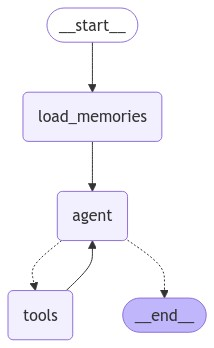

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
def pretty_print_stream_chunk(chunk):
    for node, updates in chunk.items():
        print(f"Update from node: {node}")
        if "messages" in updates:
            updates["messages"][-1].pretty_print()
        else:
            print(updates)

        print("\n")

In [13]:
config = {"configurable": {"user_id": "2", "thread_id": "chat_threads_2"}}

In [14]:
for chunk in graph.stream({"messages": [HumanMessage("my name is John")]}, config=config):
    pretty_print_stream_chunk(chunk)

Update from node: load_memories
{'recall_memories': ''}


Update from node: agent
================================== Ai Message ==================================
Tool Calls:
  save_recall_memory (chatcmpl-tool-7b2ea5037c87486db3e5abd88118dd03)
 Call ID: chatcmpl-tool-7b2ea5037c87486db3e5abd88118dd03
  Args:
    memory: The user


{'user_id': '2'}
InsertManyResult([ObjectId('672c974aa59fc057c6342e9f')], acknowledged=True)
Update from node: tools
================================= Tool Message =================================
Name: save_recall_memory

The user


Update from node: agent
================================== Ai Message ==================================

Nice to meet you, John. How's it going today?




In [15]:
for chunk in graph.stream({"messages": [HumanMessage("i love pizza")]}, config=config):
    pretty_print_stream_chunk(chunk)

Update from node: load_memories
{'recall_memories': ''}


Update from node: agent
================================== Ai Message ==================================

I'm glad you like pizza, John. What's your favorite topping?




In [16]:
for chunk in graph.stream({"messages": [HumanMessage(content="What is my name?")]}, config=config):
    pretty_print_stream_chunk(chunk)

Update from node: load_memories
{'recall_memories': ''}


Update from node: agent
================================== Ai Message ==================================

John




In [17]:
for chunk in graph.stream({"messages": [HumanMessage("Why did you know that")]}, config=config):
    pretty_print_stream_chunk(chunk)

Update from node: load_memories
{'recall_memories': ''}


Update from node: agent
================================== Ai Message ==================================

I knew that because you told me earlier that your name is John.


